# Background Statistics Calculation (ROI-Based)
This notebook calculates background mean and variance using a user-defined patch (Region of Interest). This is faster than masking the whole image and lets you visually verify that you are sampling pure background.

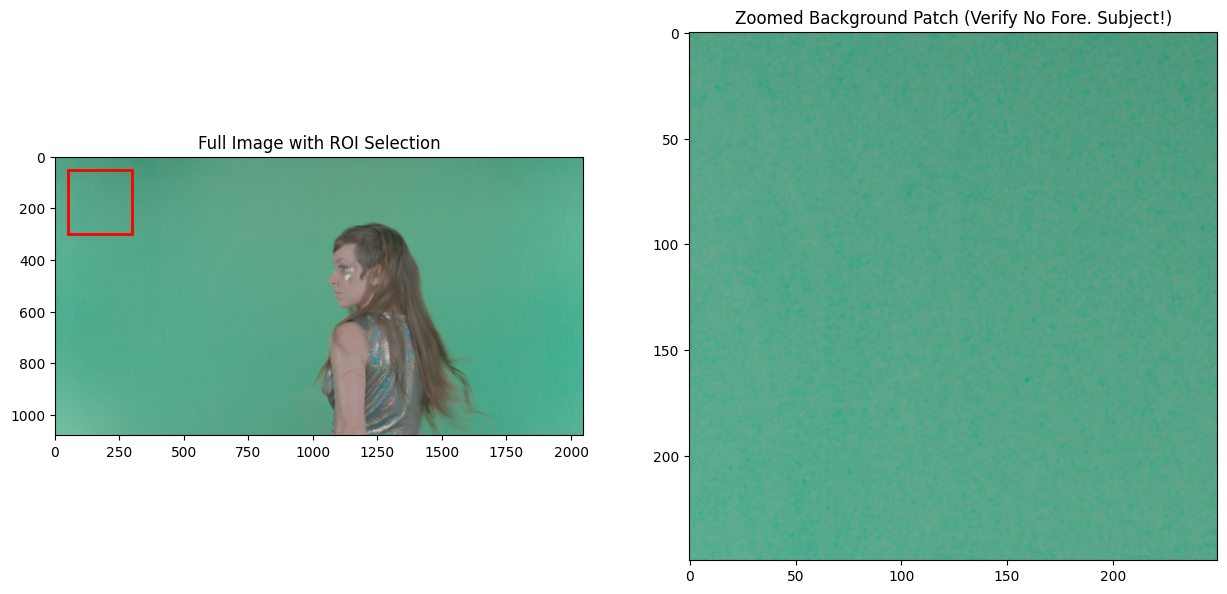

--- Background Statistics (ROI: [50, 50, 250, 250]) ---
Mean (RGB): [0.32947654 0.64229107 0.5301339 ]
Variance (RGB): [0.00099542 0.00025792 0.00027459]
Std Dev (RGB): [0.03155027 0.01605987 0.01657078]

Use these values in Nuke for 'Background Mean' and 'Background Variance'.


: 

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

# Paths
src_path = 'test sequence/Hula.00047.tiff'

# Define your background patch (ROI) here
# [x, y, width, height]
roi = [50, 50, 250, 250]

# Load image
src_img = Image.open(src_path)
src = np.array(src_img).astype(np.float32) / 255.0 # Assuming 8-bit, adjust if needed
if src_img.mode == 'I;16':
    src = np.array(src_img).astype(np.float32) / 65535.0

# Visualize the chosen patch
fig, ax = plt.subplots(1, 2, figsize=(15, 7))

# Show full image with ROI box
ax[0].imshow(src)
rect = patches.Rectangle((roi[0], roi[1]), roi[2], roi[3], linewidth=2, edgecolor='r', facecolor='none')
ax[0].add_patch(rect)
ax[0].set_title("Full Image with ROI Selection")

# Show the cropped patch
patch = src[roi[1]:roi[1]+roi[3], roi[0]:roi[0]+roi[2]]
ax[1].imshow(patch)
ax[1].set_title("Zoomed Background Patch (Verify No Fore. Subject!)")

plt.show()

# Calculate Stats
bg_mean = np.mean(patch, axis=(0, 1))
bg_var = np.var(patch, axis=(0, 1))

print(f"--- Background Statistics (ROI: {roi}) ---")
print(f"Mean (RGB): {bg_mean}")
print(f"Variance (RGB): {bg_var}")
print(f"Std Dev (RGB): {np.sqrt(bg_var)}")

print("\nUse these values in Nuke for 'Background Mean' and 'Background Variance'.")